# Big Data Methods for Economists - Group 5

In [ ]:
# Import used packages for Python Version 3.12.10 (see pyproject.toml)

import matplotlib.pyplot as plt
import numpy as np
import sklearn.datasets as datasets
import pandas as pd

print("Packages imported successfully!") 

Packages imported successfully!


In [ ]:
# Load the bike sharing dataset
bike_data = datasets.fetch_openml(name='Bike_Sharing_Demand', version=2, as_frame=True)
df = bike_data.frame

# Filter for 2012 data
df['year'] = df['year'].astype(int)
df_2012 = df[df['year'] == 1].copy()  # year=1 corresponds to 2012 in this dataset

# Extract temperature and count
X = df_2012['temp'].values.astype(float)
y = df_2012['count'].values.astype(float)

# Aggregate data daily
df_2012['datetime'] = pd.to_datetime(df_2012.index)
df_daily = df_2012.groupby(df_2012.index.astype(str).str[:10]).agg({'temp': 'mean', 'count': 'sum'}).reset_index()
X = df_daily['temp'].values.astype(float)
y = df_daily['count'].values.astype(float)

# Sort for plotting
sort_idx = np.argsort(X)
X_sorted = X[sort_idx]
y_sorted = y[sort_idx]

X_plot = np.linspace(X.min(), X.max(), 300)

# --- OLS (degree 1) ---
ols_coeffs = np.polyfit(X, y, 1)
ols_pred = np.polyval(ols_coeffs, X_plot)

# --- Polynomial Regression (degree 5) ---
poly_coeffs = np.polyfit(X, y, 5)
poly_pred = np.polyval(poly_coeffs, X_plot)

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(X, y, alpha=0.15, color='gray', s=10, label='Data')
ax.plot(X_plot, ols_pred, color='royalblue', linewidth=2.5, label='OLS (degree 1)')
ax.plot(X_plot, poly_pred, color='tomato', linewidth=2.5, label='Polynomial (degree 5)')
ax.set_xlabel('Temperature (normalized)', fontsize=12)
ax.set_ylabel('Bike Rentals (count)', fontsize=12)

ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.title('Bike Sharing: Temperature vs Rentals (2012)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

NameError: name 'pd' is not defined

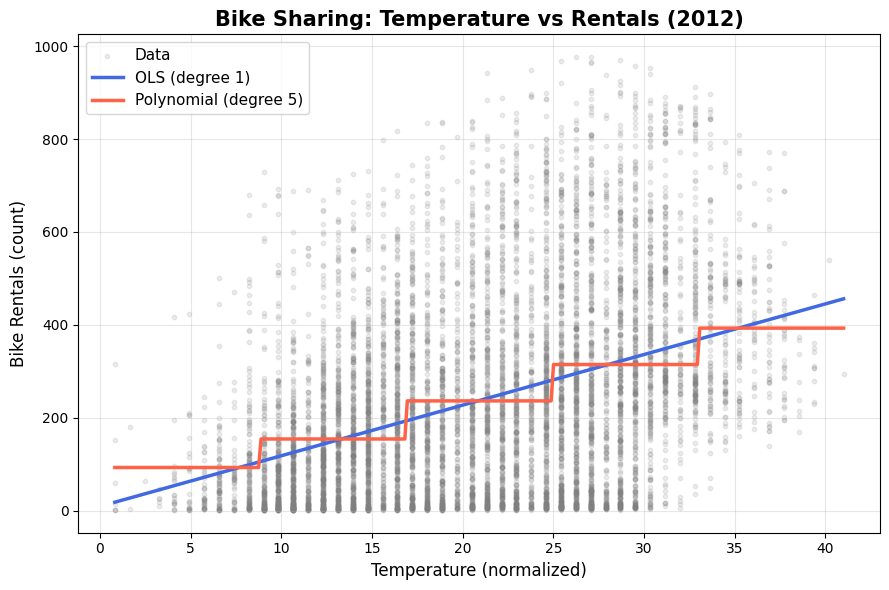

In [6]:
# Load the bike sharing dataset
bike_data = datasets.fetch_openml(name='Bike_Sharing_Demand', version=2, as_frame=True)
df = bike_data.frame

# Filter for 2012 data
df['year'] = df['year'].astype(int)
df_2012 = df[df['year'] == 1].copy()  # year=1 corresponds to 2012 in this dataset

# Extract temperature and count
X = df_2012['temp'].values.astype(float)
y = df_2012['count'].values.astype(float)

# Sort for plotting
sort_idx = np.argsort(X)
X_sorted = X[sort_idx]
y_sorted = y[sort_idx]

X_plot = np.linspace(X.min(), X.max(), 300)

# --- OLS (degree 1) ---
ols_coeffs = np.polyfit(X, y, 1)
ols_pred = np.polyval(ols_coeffs, X_plot)

# --- Polynomial Regression (degree 5) ---
# --- Step Function Regression (5 steps) ---
n_steps = 5
bins = np.linspace(X.min(), X.max(), n_steps + 1)
bin_indices = np.digitize(X, bins[1:-1])  # assign each X to a bin

step_pred = np.zeros(len(X_plot))
for i in range(n_steps):
    mask = bin_indices == i
    if mask.sum() > 0:
        step_mean = y[mask].mean()
    plot_mask = (X_plot >= bins[i]) & (X_plot < bins[i + 1])
    step_pred[plot_mask] = step_mean
step_pred[X_plot >= bins[-1]] = step_mean  # fill last bin edge
poly_pred = step_pred

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(X, y, alpha=0.15, color='gray', s=10, label='Data')
ax.plot(X_plot, ols_pred, color='royalblue', linewidth=2.5, label='OLS (degree 1)')
ax.plot(X_plot, poly_pred, color='tomato', linewidth=2.5, label='Polynomial (degree 5)')
ax.set_xlabel('Temperature (normalized)', fontsize=12)
ax.set_ylabel('Bike Rentals (count)', fontsize=12)

ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.title('Bike Sharing: Temperature vs Rentals (2012)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

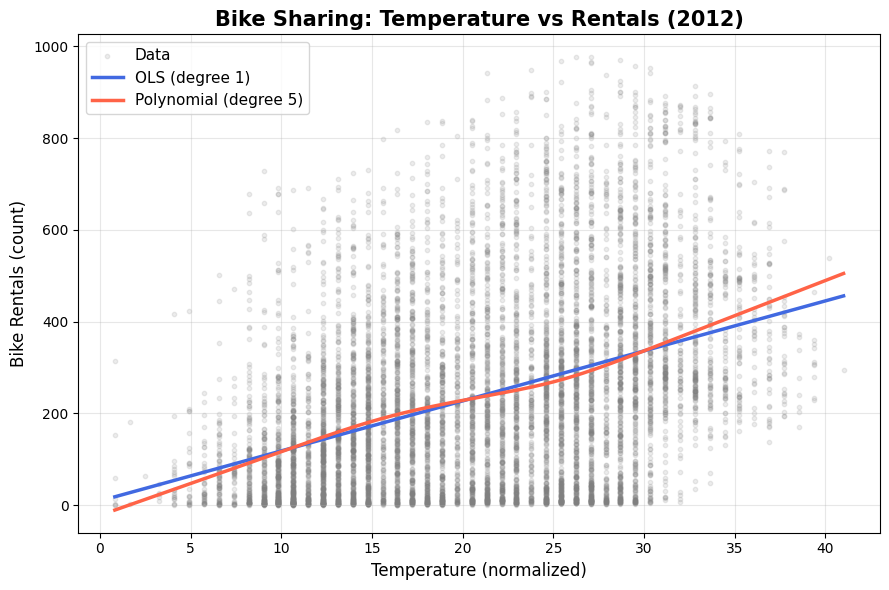

In [7]:
from numpy.polynomial import polynomial as P

# Load the bike sharing dataset
bike_data = datasets.fetch_openml(name='Bike_Sharing_Demand', version=2, as_frame=True)
df = bike_data.frame

# Filter for 2012 data
df['year'] = df['year'].astype(int)
df_2012 = df[df['year'] == 1].copy()  # year=1 corresponds to 2012 in this dataset

# Extract temperature and count
X = df_2012['temp'].values.astype(float)
y = df_2012['count'].values.astype(float)

# Sort for plotting
sort_idx = np.argsort(X)
X_sorted = X[sort_idx]
y_sorted = y[sort_idx]

X_plot = np.linspace(X.min(), X.max(), 300)

# --- OLS (degree 1) ---
ols_coeffs = np.polyfit(X, y, 1)
ols_pred = np.polyval(ols_coeffs, X_plot)

# --- Basis Function Regression (Natural Cubic Spline with 5 knots) ---

n_knots = 5
knots = np.quantile(X, np.linspace(0.1, 0.9, n_knots))

def natural_cubic_spline_basis(x, knots):
    """Create natural cubic spline basis matrix."""
    n = len(knots)
    basis = [np.ones_like(x), x]
    for k in knots[:-1]:
        d = (np.maximum(x - k, 0)**3 - np.maximum(x - knots[-1], 0)**3) / (knots[-1] - k)
        d_prev = (np.maximum(x - knots[-2], 0)**3 - np.maximum(x - knots[-1], 0)**3) / (knots[-1] - knots[-2])
        basis.append(d - d_prev)
    return np.column_stack(basis)

B_train = natural_cubic_spline_basis(X, knots)
B_plot = natural_cubic_spline_basis(X_plot, knots)

# Fit via OLS: beta = (B'B)^{-1} B'y
beta = np.linalg.lstsq(B_train, y, rcond=None)[0]
poly_pred = B_plot @ beta

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(X, y, alpha=0.15, color='gray', s=10, label='Data')
ax.plot(X_plot, ols_pred, color='royalblue', linewidth=2.5, label='OLS (degree 1)')
ax.plot(X_plot, poly_pred, color='tomato', linewidth=2.5, label='Polynomial (degree 5)')
ax.set_xlabel('Temperature (normalized)', fontsize=12)
ax.set_ylabel('Bike Rentals (count)', fontsize=12)

ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.title('Bike Sharing: Temperature vs Rentals (2012)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

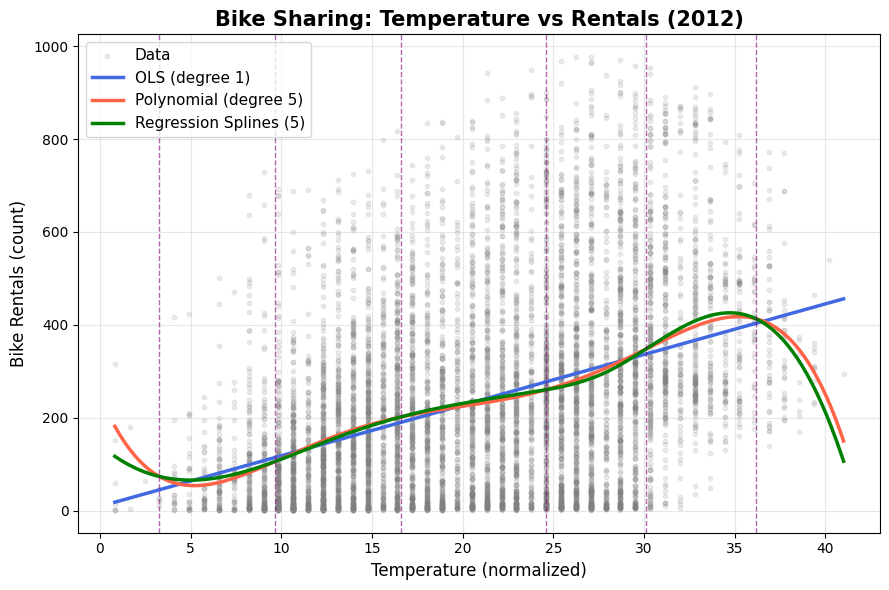

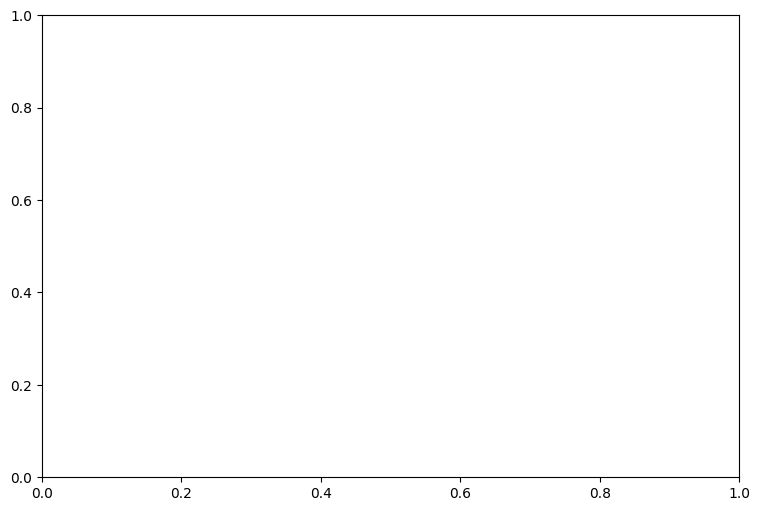

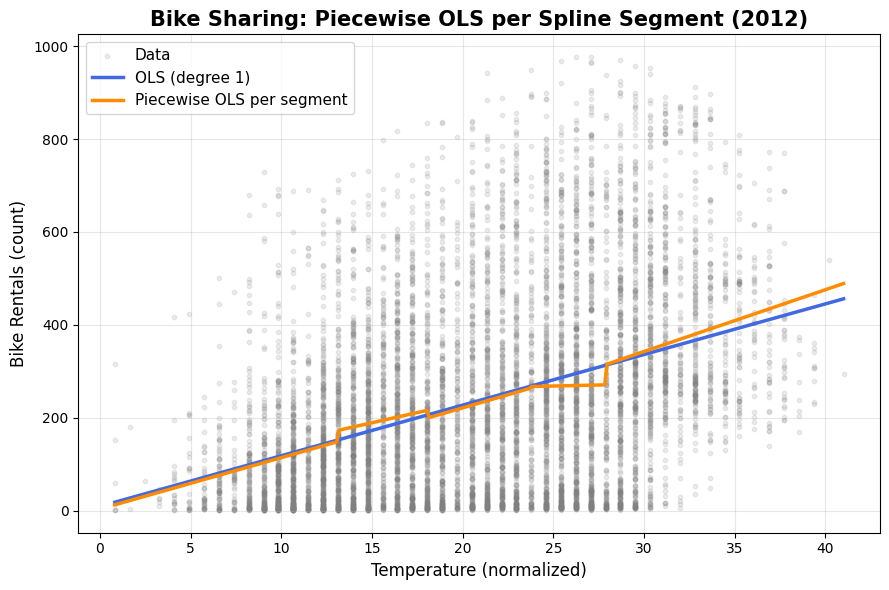

In [11]:
# Extract temperature and count (reuse from existing variables)
X_plot = np.linspace(X.min(), X.max(), 300)

# --- OLS (degree 1) ---
ols_coeffs = np.polyfit(X, y, 1)
ols_pred = np.polyval(ols_coeffs, X_plot)

# --- Polynomial Regression (degree 5) ---
poly_coeffs = np.polyfit(X, y, 5)
poly_pred = np.polyval(poly_coeffs, X_plot)

# --- Regression Splines (5 basis splines with 4 interior knots) ---
n_knots = 4
knots_rs = np.quantile(X, np.linspace(0.2, 0.8, n_knots))

def regression_spline_basis(x, knots):
    """Create regression spline (truncated power) basis matrix."""
    basis = [np.ones_like(x), x, x**2, x**3]
    for k in knots:
        basis.append(np.maximum(x - k, 0)**3)
    return np.column_stack(basis)

# --- Compute intersection points between spline and polynomial predictions ---
diff = spline_pred - poly_pred
sign_changes = np.where(np.diff(np.sign(diff)))[0]
intersect_x = [X_plot[i] + (X_plot[i+1] - X_plot[i]) * (-diff[i] / (diff[i+1] - diff[i])) for i in sign_changes]

B_train_rs = regression_spline_basis(X, knots_rs)
B_plot_rs = regression_spline_basis(X_plot, knots_rs)

beta_rs = np.linalg.lstsq(B_train_rs, y, rcond=None)[0]
spline_pred = B_plot_rs @ beta_rs

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(X, y, alpha=0.15, color='gray', s=10, label='Data')
ax.plot(X_plot, ols_pred, color='royalblue', linewidth=2.5, label='OLS (degree 1)')
ax.plot(X_plot, poly_pred, color='tomato', linewidth=2.5, label='Polynomial (degree 5)')
ax.plot(X_plot, spline_pred, color='green', linewidth=2.5, label='Regression Splines (5)')
ax.set_xlabel('Temperature (normalized)', fontsize=12)
ax.set_ylabel('Bike Rentals (count)', fontsize=12)

for ix in intersect_x:
    ax.axvline(x=ix, color='purple', linewidth=1, linestyle='--', alpha=0.6)

ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.title('Bike Sharing: Temperature vs Rentals (2012)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
# --- Piecewise OLS per spline segment (using knots_rs as breakpoints) ---
breakpoints = np.concatenate([[X.min()], knots_rs, [X.max()]])
spline_pred_piecewise = np.zeros(len(X_plot))

for seg in range(len(breakpoints) - 1):
    seg_mask_train = (X >= breakpoints[seg]) & (X <= breakpoints[seg + 1])
    seg_mask_plot = (X_plot >= breakpoints[seg]) & (X_plot <= breakpoints[seg + 1])
    if seg_mask_train.sum() > 1:
        X_seg = X[seg_mask_train]
        y_seg = y[seg_mask_train]
        A = np.column_stack([np.ones_like(X_seg), X_seg])
        beta_seg = np.linalg.lstsq(A, y_seg, rcond=None)[0]
        X_plot_seg = X_plot[seg_mask_plot]
        spline_pred_piecewise[seg_mask_plot] = beta_seg[0] + beta_seg[1] * X_plot_seg

ax2, fig2 = plt.subplots if False else (None, plt.subplots(figsize=(9, 6)))
fig2, ax2 = plt.subplots(figsize=(9, 6))
ax2.scatter(X, y, alpha=0.15, color='gray', s=10, label='Data')
ax2.plot(X_plot, ols_pred, color='royalblue', linewidth=2.5, label='OLS (degree 1)')
ax2.plot(X_plot, spline_pred_piecewise, color='darkorange', linewidth=2.5, label='Piecewise OLS per segment')
ax2.set_xlabel('Temperature (normalized)', fontsize=12)
ax2.set_ylabel('Bike Rentals (count)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
plt.title('Bike Sharing: Piecewise OLS per Spline Segment (2012)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

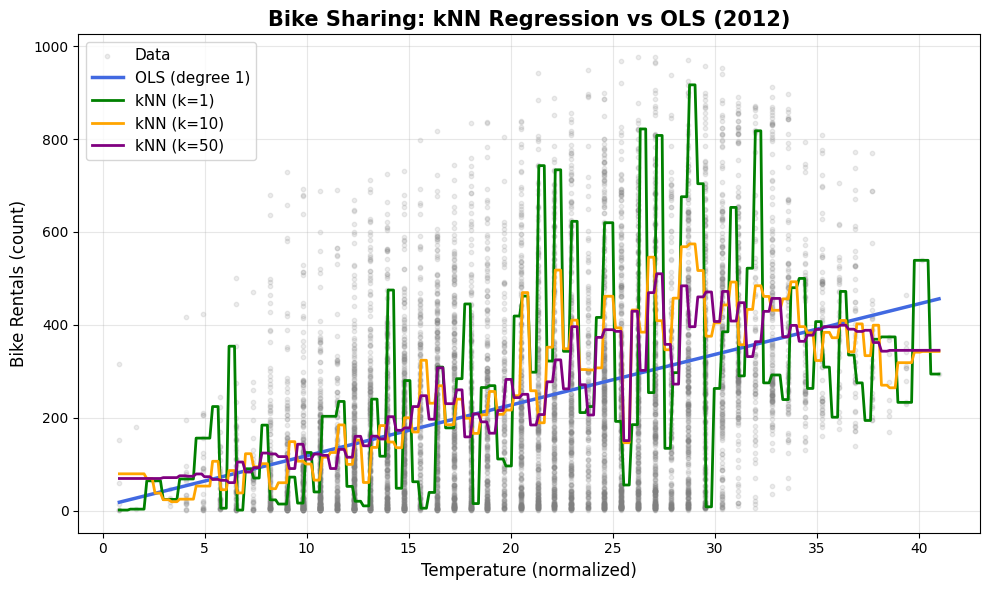

In [13]:
from sklearn.neighbors import KNeighborsRegressor

# Prepare data
X_2d = X.reshape(-1, 1)
X_plot_2d = X_plot.reshape(-1, 1)

# Fit kNN for different k values
k_values = [1, 10, 50]
colors = ['green', 'orange', 'purple']
knn_preds = {}

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_2d, y)
    knn_preds[k] = knn.predict(X_plot_2d)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X, y, alpha=0.15, color='gray', s=10, label='Data')
ax.plot(X_plot, ols_pred, color='royalblue', linewidth=2.5, label='OLS (degree 1)')

for k, color in zip(k_values, colors):
    ax.plot(X_plot, knn_preds[k], linewidth=2, color=color, label=f'kNN (k={k})')

ax.set_xlabel('Temperature (normalized)', fontsize=12)
ax.set_ylabel('Bike Rentals (count)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.title('Bike Sharing: kNN Regression vs OLS (2012)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

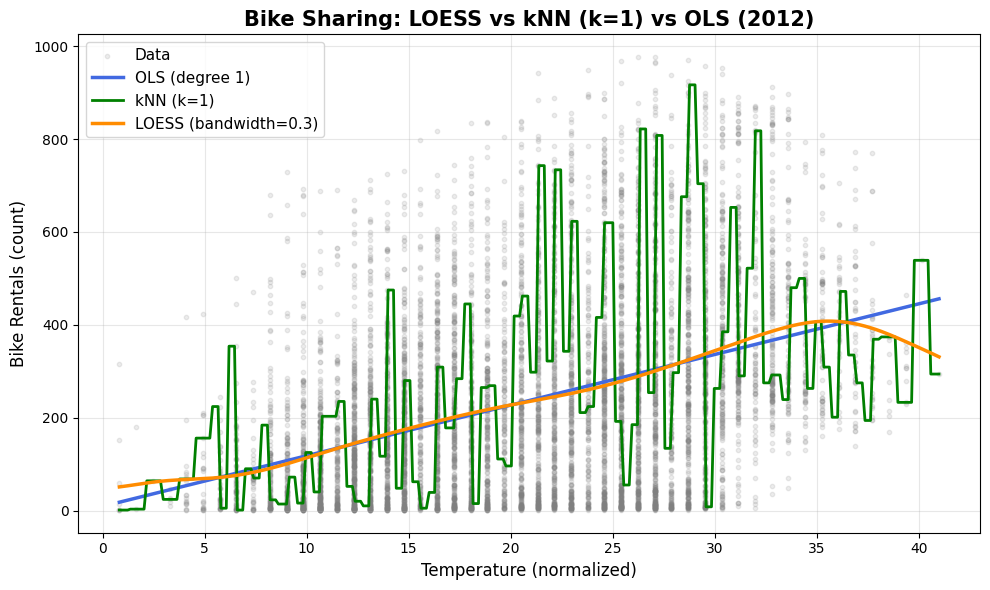

In [14]:
from sklearn.linear_model import LinearRegression

# --- LOESS implementation ---
def loess(x_train, y_train, x_pred, bandwidth=0.3):
    """Local regression (LOESS) using tricubic kernel weights."""
    n = len(x_train)
    x_range = x_train.max() - x_train.min()
    
    predictions = np.zeros(len(x_pred))
    for i, x0 in enumerate(x_pred):
        # Compute distances and weights (tricubic kernel)
        distances = np.abs(x_train - x0)
        h = bandwidth * x_range
        u = distances / h
        weights = np.where(u < 1, (1 - u**3)**3, 0)
        
        # Weighted OLS: fit local linear model
        if weights.sum() > 0:
            W = np.diag(weights)
            A = np.column_stack([np.ones(n), x_train])
            beta = np.linalg.lstsq(W @ A, W @ y_train, rcond=None)[0]
            predictions[i] = beta[0] + beta[1] * x0
    return predictions

# Compute LOESS predictions
loess_pred = loess(X, y, X_plot, bandwidth=0.3)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X, y, alpha=0.15, color='gray', s=10, label='Data')
ax.plot(X_plot, ols_pred, color='royalblue', linewidth=2.5, label='OLS (degree 1)')
ax.plot(X_plot, knn_preds[1], color='green', linewidth=2, label='kNN (k=1)')
ax.plot(X_plot, loess_pred, color='darkorange', linewidth=2.5, label='LOESS (bandwidth=0.3)')

ax.set_xlabel('Temperature (normalized)', fontsize=12)
ax.set_ylabel('Bike Rentals (count)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.title('Bike Sharing: LOESS vs kNN (k=1) vs OLS (2012)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

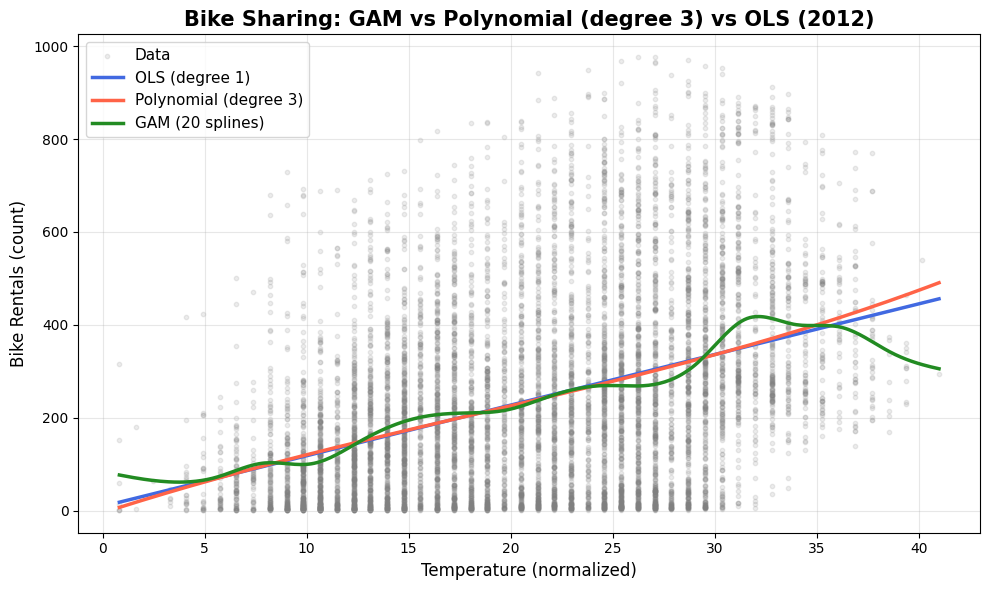

In [16]:
from pygam import LinearGAM, s

# --- Polynomial Regression (degree 3) ---
poly3_coeffs = np.polyfit(X, y, 3)
poly3_pred = np.polyval(poly3_coeffs, X_plot)

# --- GAM with spline term ---
gam = LinearGAM(s(0, n_splines=20, spline_order=3)).fit(X.reshape(-1, 1), y)
gam_pred = gam.predict(X_plot.reshape(-1, 1))

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X, y, alpha=0.15, color='gray', s=10, label='Data')
ax.plot(X_plot, ols_pred, color='royalblue', linewidth=2.5, label='OLS (degree 1)')
ax.plot(X_plot, poly3_pred, color='tomato', linewidth=2.5, label='Polynomial (degree 3)')
ax.plot(X_plot, gam_pred, color='forestgreen', linewidth=2.5, label='GAM (20 splines)')

ax.set_xlabel('Temperature (normalized)', fontsize=12)
ax.set_ylabel('Bike Rentals (count)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.title('Bike Sharing: GAM vs Polynomial (degree 3) vs OLS (2012)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()